In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from numpy import mean
from pandas import Series

pd.set_option("display.max_columns",200)

In [39]:
data = pd.read_csv("./dataset/student.csv")

In [40]:
data = pd.DataFrame(data)

In [41]:
df = data

In [16]:
df.head()

,Age,Grade,Gender,Race,SES_Quartile,ParentalEducation,SchoolType,Locale,TestScore_Math,TestScore_Reading,TestScore_Science,GPA,AttendanceRate,StudyHours,InternetAccess,Extracurricular,PartTimeJob,ParentSupport,Romantic,FreeTime,GoOut
0,15,10,Female,White,1,HS,Public,City,72.346053,62.217134,73.008079,2.521745,0.868836,0.310172,0,1,1,1,0,3,3
1,16,11,Female,Hispanic,1,<HS,Private,City,77.889157,72.748030,76.303717,3.275626,0.909595,1.175586,1,1,0,0,1,3,1
2,17,12,Female,Black,2,HS,Public,Rural,72.966587,65.585472,68.099411,2.974137,0.870952,1.112556,1,1,0,0,0,3,3
3,16,11,Female,White,2,HS,Public,Town,96.674049,88.035852,100.000000,3.676590,1.000000,1.067679,0,0,0,0,1,4,5
4,16,11,Male,Black,3,Bachelors+,Public,Rural,81.989270,77.485372,72.715066,2.255014,0.897957,0.841936,0,1,0,1,0,4,2


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999997 entries, 0 to 999996
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                999997 non-null  int64  
 1   Grade              999997 non-null  int64  
 2   Gender             999997 non-null  object 
 3   Race               999997 non-null  object 
 4   SES_Quartile       999997 non-null  int64  
 5   ParentalEducation  999997 non-null  object 
 6   SchoolType         999997 non-null  object 
 7   Locale             999997 non-null  object 
 8   TestScore_Math     999997 non-null  float64
 9   TestScore_Reading  999997 non-null  float64
 10  TestScore_Science  999997 non-null  float64
 11  GPA                999997 non-null  float64
 12  AttendanceRate     999997 non-null  float64
 13  StudyHours         999997 non-null  float64
 14  InternetAccess     999997 non-null  int64  
 15  Extracurricular    999997 non-null  int64  
 16  Pa

In [30]:
df.isna().sum()

Age                  0
Grade                0
Gender               0
Race                 0
SES_Quartile         0
ParentalEducation    0
SchoolType           0
Locale               0
TestScore_Math       0
TestScore_Reading    0
TestScore_Science    0
GPA                  0
AttendanceRate       0
StudyHours           0
InternetAccess       0
Extracurricular      0
PartTimeJob          0
ParentSupport        0
Romantic             0
FreeTime             0
GoOut                0
dtype: int64

#### what are the no of students from SES_Quartile 1 who are attending college ?

In [20]:
q1 = df.query("ParentalEducation == 'SomeCollege' | ParentalEducation == 'Bachelors+'").groupby("SES_Quartile")["ParentalEducation"].value_counts().rename("StudentCount").reset_index()
q1

,SES_Quartile,ParentalEducation,StudentCount
0,1,SomeCollege,37304
1,1,Bachelors+,12418
2,2,SomeCollege,75382
3,2,Bachelors+,24965
4,3,SomeCollege,100373
5,3,Bachelors+,49995
6,4,Bachelors+,100023
7,4,SomeCollege,87421


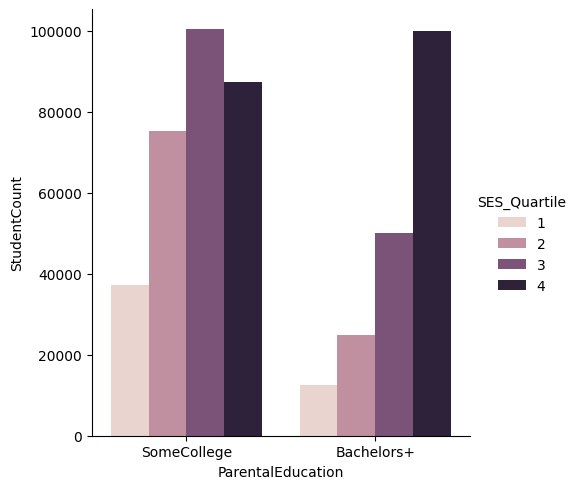

In [21]:
graph = sns.catplot(
    data=q1, kind="bar",
    x="ParentalEducation", y="StudentCount", hue="SES_Quartile"
)

In [22]:
q1.loc[(q1["SES_Quartile"] == 1),["StudentCount"]].sum()

StudentCount    49722
dtype: int64

* There are about 49722 students who are are atteding college
* The no of people attending higher education such as Bachelors Degrees increases according to the students socio economic status

#### Analyze the Relationship between SES Quartile and The no of students 

In [23]:
q2 = df.groupby("SES_Quartile")["ParentalEducation"].value_counts().rename("StudentCount").reset_index()
q2

,SES_Quartile,ParentalEducation,StudentCount
0,1,HS,100306
1,1,<HS,99833
2,1,SomeCollege,37304
3,1,Bachelors+,12418
4,2,HS,99960
5,2,SomeCollege,75382
6,2,<HS,49661
7,2,Bachelors+,24965
8,3,SomeCollege,100373
9,3,HS,74957


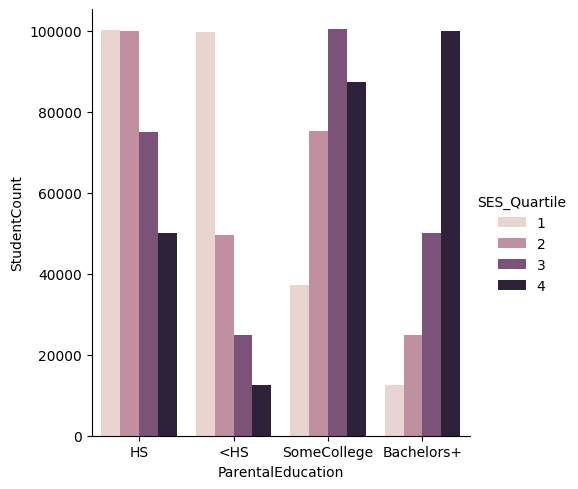

In [27]:
sns.catplot(
    data = q2,x = "ParentalEducation",y="StudentCount",hue="SES_Quartile",kind="bar"
)

* considering the SES_Quartile 1 the no of students is gradually decreasing with the increase in education level
* remaining SES_Quartile is not showing a ny direct relation with the Education level

#### Find the Top Scoring students from each Locale both male and female,From each Educational Levels

In [36]:
df.sort_values("GPA",ascending=False).groupby(["Locale","Gender","ParentalEducation"],as_index = False)[["ParentalEducation","GPA","Gender"]].first()

,Locale,ParentalEducation,GPA,Gender
0,City,<HS,4.0,Female
1,City,Bachelors+,4.0,Female
2,City,HS,4.0,Female
3,City,SomeCollege,4.0,Female
4,City,<HS,4.0,Male
5,City,Bachelors+,4.0,Male
6,City,HS,4.0,Male
7,City,SomeCollege,4.0,Male
8,Rural,<HS,4.0,Female
9,Rural,Bachelors+,4.0,Female


#### Find the Unique Values in the dataset for Race,Grade,ParentalEducation,Age and Locale

In [12]:
print("Race :-",df["Race"].unique())
print("Grade :-",df["Grade"].unique())
print("ParentalEducation :-",df["ParentalEducation"].unique())
print("Age :-",df["Age"].unique())
print("Locale :-",df["Locale"].unique())

Race :- ['White' 'Hispanic' 'Black' 'Asian' 'Two-or-more' 'Other']
Grade :- [10 11 12  9]
ParentalEducation :- ['HS' '<HS' 'Bachelors+' 'SomeCollege']
Age :- [15 16 17 14 18]
Locale :- ['City' 'Rural' 'Town' 'Suburban']


* The dataset contains the educational information of students of age group 15 to 18 From different race,Locale and socioEconomic Status

#### How many Male and Female Students are there

In [22]:
df.groupby("Gender")["Age"].count()

Gender
Female    510091
Male      489906
Name: Age, dtype: int64

* the dataset contains about male and Female students data of same proportion

#### Which Locale has highest number of students who are going to Bachelor+

In [46]:
q4 = df.loc[(df["ParentalEducation"] == "Bachelors+")].groupby(["Locale","Gender"],as_index = False).size()

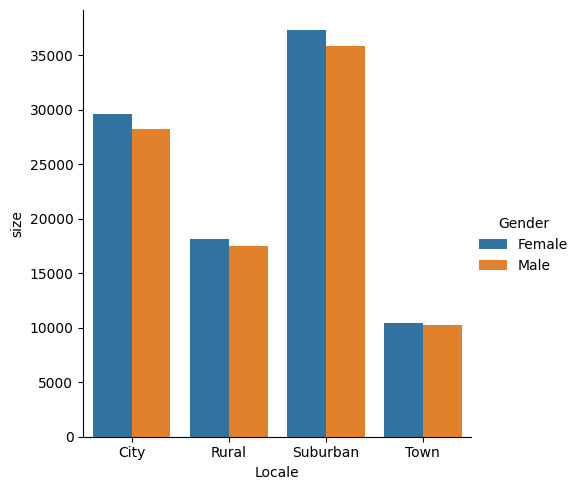

In [48]:
sns.catplot(data=q4,x = "Locale",y = "size",hue = "Gender",kind = "bar")

* majority of the students who are pursuing bachelor+ course are in suburban
* a very few students are in town

#### What is the most attended ParentalEducation in each Locale

In [54]:
q5 = df.groupby(["Locale","ParentalEducation"],as_index = False)[["Locale","ParentalEducation","Gender"]].size().sort_values("size",ascending = False).drop_duplicates("Locale")
q5

,Locale,ParentalEducation,size
10,Suburban,HS,127485
2,City,HS,100539
6,Rural,HS,61487
14,Town,HS,35757


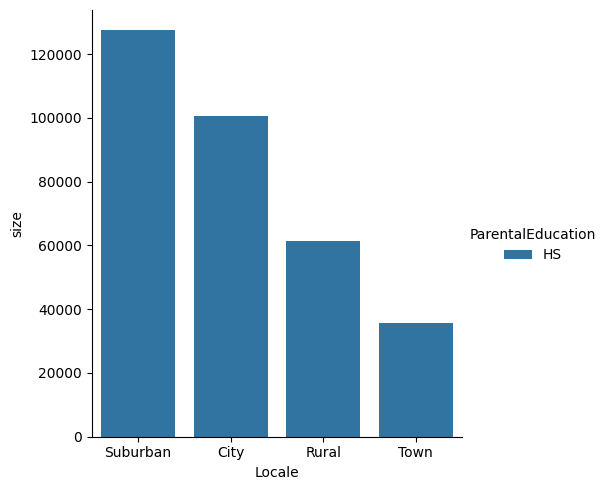

In [57]:
sns.catplot(data=q5,x = "Locale",y = "size",hue = "ParentalEducation",kind = "bar")

* most students are studying in suburban area for HS education 
* similar to Later the least number of students are studying on Town area

#### analyze how many students are there in each locale ,their Parental education and GPA

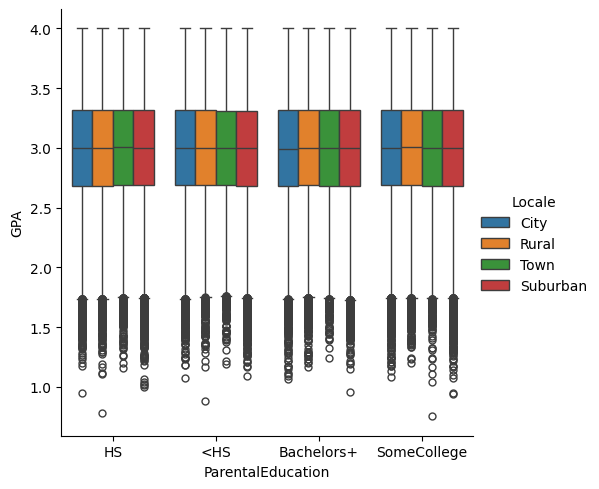

In [58]:
sns.catplot(data = df,x = "ParentalEducation",y = "GPA",hue = "Locale",kind = "box")

* 25% of the studnets scored GPA arount 0 - 2.75
* 50% scored GPA around 2.25 to 3.25
* and the top 25 % stored from around 3.25 to 4

#### analyze each locale and Parental education where the most student are choose for education

In [63]:
q6 =  df.groupby("ParentalEducation",as_index = False)["Locale","ParentalEducation"].size()
q6

ValueError: Cannot subset columns with a tuple with more than one element. Use a list instead.

In [ ]:
sns.catplot(data = q6,x = "Parental_Education",y = "size",hue = "")

#### monitor the StudyHours and GPA of the students

<Axes: xlabel='GPA', ylabel='StudyHours'>

C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


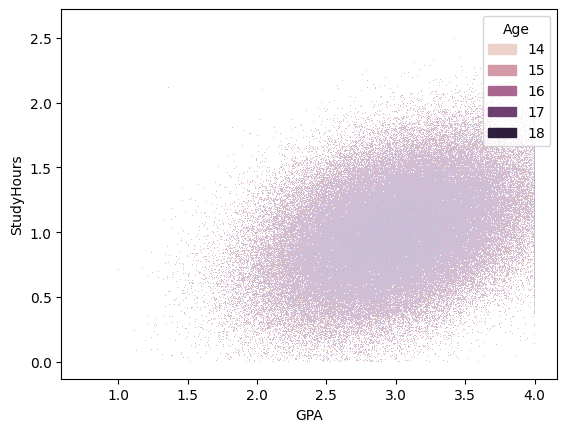

In [11]:
sns.histplot(data = df[["GPA","StudyHours","Age"]],x = "GPA",y = "StudyHours",hue = "Age",bins=1000 )

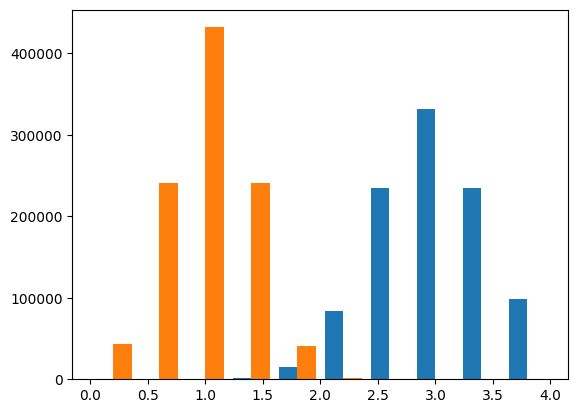

In [8]:
plt.hist(df[["GPA","StudyHours"]])
plt.show()

* the histogram fromed a elipse like shape with the colour gradally becoming darker , indicates the increase in age
of the students
* majority of the students from age group 18 study btw .5 to 1.5 hrs and scores and average gpa ntw 2.5 to 3.5

#### what is the relation between the GPA,atttendance, and test score marks

<Axes: >

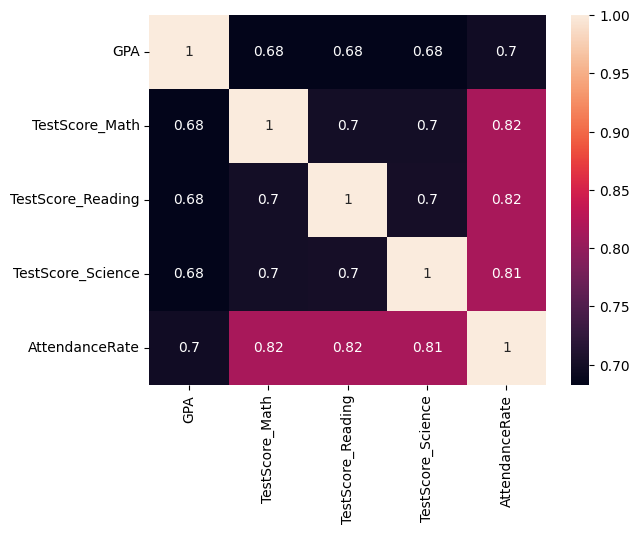

In [81]:
correlated = df[["GPA","TestScore_Math","TestScore_Reading","TestScore_Science","AttendanceRate"]].corr()
sns.heatmap(data = correlated,annot = True)

* The correlation value of each elements is greater than .5 which means the every columns are lineraly related to each other
* especially attendance rate is highly dependant on the Testscores and less on GPA

#### Does internet Access actually increase ones GPA

In [23]:
df.loc[(df["InternetAccess"] == 1),:].groupby(["ParentalEducation","Locale","Race"])["GPA"].size()

ParentalEducation  Locale  Race       
<HS                City    Asian           2290
                           Black           6615
                           Hispanic       13012
                           Other            922
                           Two-or-more     2160
                                          ...  
SomeCollege        Town    Black           4340
                           Hispanic        8318
                           Other            613
                           Two-or-more     1422
                           White          12860
Name: GPA, Length: 96, dtype: int64

In [13]:
InternetAccess1=df.loc[(df["InternetAccess"] == 1),:]
InternetAccess1

,Age,Grade,Gender,Race,SES_Quartile,ParentalEducation,SchoolType,Locale,TestScore_Math,TestScore_Reading,TestScore_Science,GPA,AttendanceRate,StudyHours,InternetAccess,Extracurricular,PartTimeJob,ParentSupport,Romantic,FreeTime,GoOut
1,16,11,Female,Hispanic,1,<HS,Private,City,77.889157,72.748030,76.303717,3.275626,0.909595,1.175586,1,1,0,0,1,3,1
2,17,12,Female,Black,2,HS,Public,Rural,72.966587,65.585472,68.099411,2.974137,0.870952,1.112556,1,1,0,0,0,3,3
5,15,10,Male,White,3,HS,Public,City,62.374548,68.392390,53.799441,2.834226,0.811898,0.605655,1,1,0,0,0,2,1
6,14,9,Male,Hispanic,3,SomeCollege,Public,City,67.035362,81.634238,80.751897,2.920480,0.921736,0.888149,1,1,0,0,0,2,1
7,16,11,Female,Asian,3,SomeCollege,Public,City,78.758040,64.555005,83.232377,3.424940,0.892412,0.832819,1,1,0,0,0,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999990,16,11,Male,Hispanic,1,HS,Public,Suburban,65.595525,62.055118,69.511465,2.728359,0.851288,1.035154,1,0,0,1,0,1,1
999991,14,9,Male,Hispanic,3,Bachelors+,Public,Suburban,92.489961,80.228335,75.084046,3.250303,0.927415,1.131533,1,1,0,0,0,4,1
999992,15,10,Male,White,1,SomeCollege,Public,City,85.027753,79.332115,94.840167,3.745234,0.954076,1.539429,1,1,0,0,0,2,3
999994,16,11,Male,White,2,Bachelors+,Public,Suburban,46.145953,57.071174,64.636155,1.763198,0.783701,0.268388,1,1,1,1,0,3,1


<Axes: xlabel='ParentalEducation,Locale,Race'>

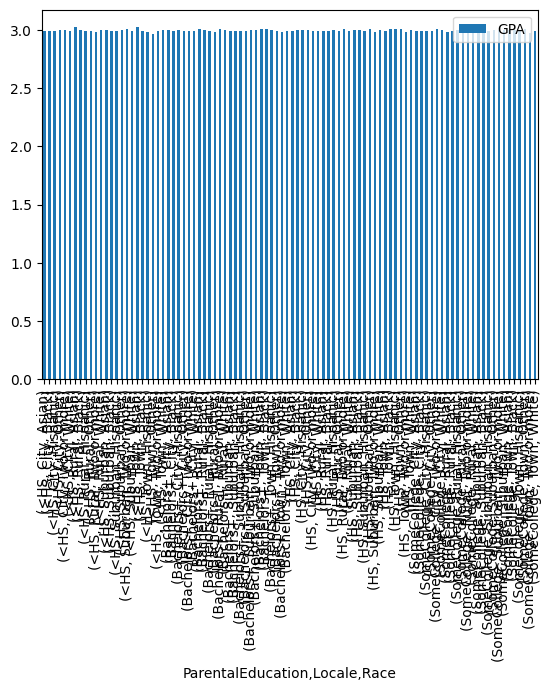

In [14]:
InternetAccess1.groupby(["ParentalEducation","Locale","Race"])["GPA"].mean().to_frame().plot(kind="bar")

In [15]:
q9 = InternetAccess1.groupby(["ParentalEducation","Locale","Race"],as_index = False)["GPA"].agg([mean,len])
q9

C:\Users\USER\AppData\Local\Temp\ipykernel_14148\774319197.py:1: FutureWarning: The provided callable <function mean at 0x00000207E2E6AF80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  q9 = InternetAccess1.groupby(["ParentalEducation","Locale","Race"],as_index = False)["GPA"].agg([mean,len])


,ParentalEducation,Locale,Race,mean,len
0,<HS,City,Asian,2.990656,2290
1,<HS,City,Black,2.995547,6615
2,<HS,City,Hispanic,2.995722,13012
3,<HS,City,Other,2.997512,922
4,<HS,City,Two-or-more,3.000784,2160
...,...,...,...,...,...
91,SomeCollege,Town,Black,2.997212,4340
92,SomeCollege,Town,Hispanic,2.994655,8318
93,SomeCollege,Town,Other,3.008636,613
94,SomeCollege,Town,Two-or-more,2.978720,1422


In [17]:
np.round(q9["mean"],2)

0     2.99
1     3.00
2     3.00
3     3.00
4     3.00
      ... 
91    3.00
92    2.99
93    3.01
94    2.98
95    2.99
Name: mean, Length: 96, dtype: float64

In [18]:
q9["mean"] = np.round(q9["mean"],2)

<Axes: xlabel='mean', ylabel='len'>

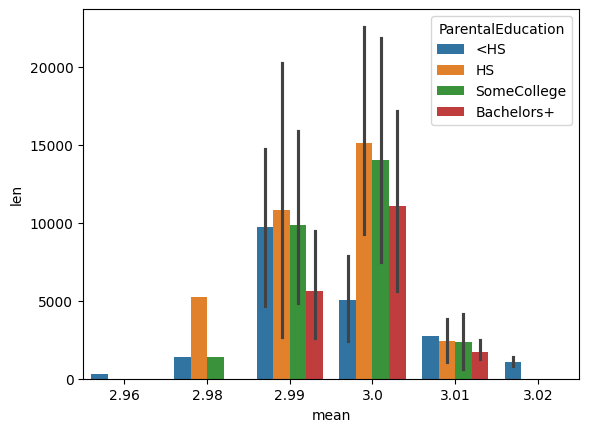

In [25]:
sns.barplot(data = q9,x = "mean",y = "len",hue = "ParentalEducation")

#### in which grade we have most no of asian people and what was their parental Education

In [11]:
df.columns

Index(['Age', 'Grade', 'Gender', 'Race', 'SES_Quartile', 'ParentalEducation',
       'SchoolType', 'Locale', 'TestScore_Math', 'TestScore_Reading',
       'TestScore_Science', 'GPA', 'AttendanceRate', 'StudyHours',
       'InternetAccess', 'Extracurricular', 'PartTimeJob', 'ParentSupport',
       'Romantic', 'FreeTime', 'GoOut'],
      dtype='object')

In [21]:
q10 = df.loc[(df["Race"] == "Asian"),["GPA","Grade","Race","ParentalEducation"]].groupby(["Grade","ParentalEducation"],as_index=False).size()
q10

,Grade,ParentalEducation,size
0,9,<HS,1869
1,9,Bachelors+,1795
2,9,HS,3190
3,9,SomeCollege,2960
4,10,<HS,1897
5,10,Bachelors+,1875
6,10,HS,3182
7,10,SomeCollege,3045
8,11,<HS,1816
9,11,Bachelors+,1890


<Axes: xlabel='ParentalEducation', ylabel='size'>

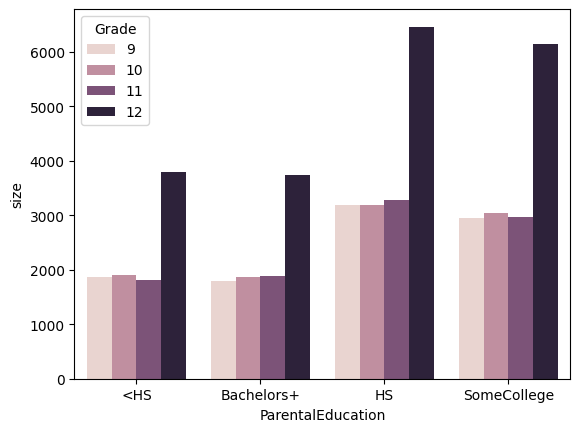

In [19]:
sns.barplot(data= q10,x = "ParentalEducation",y="size",hue = "Grade")

* majority of the asian students studied on grade 12
* the highest number of asian students studien was on grade 12 HS parental education

#### What is the types of Schooling Preffered for each race

In [28]:
q11 = df[["Race","ParentalEducation","SchoolType","Age"]].groupby(["ParentalEducation","Race","SchoolType"],as_index = False)["Age"].size()
q11

,ParentalEducation,Race,SchoolType,size
0,<HS,Asian,Private,1141
1,<HS,Asian,Public,8235
2,<HS,Black,Private,3316
3,<HS,Black,Public,24592
4,<HS,Hispanic,Private,6340
5,<HS,Hispanic,Public,47896
6,<HS,Other,Private,453
7,<HS,Other,Public,3337
8,<HS,Two-or-more,Private,1149
9,<HS,Two-or-more,Public,8090


<Axes: xlabel='SchoolType', ylabel='size'>

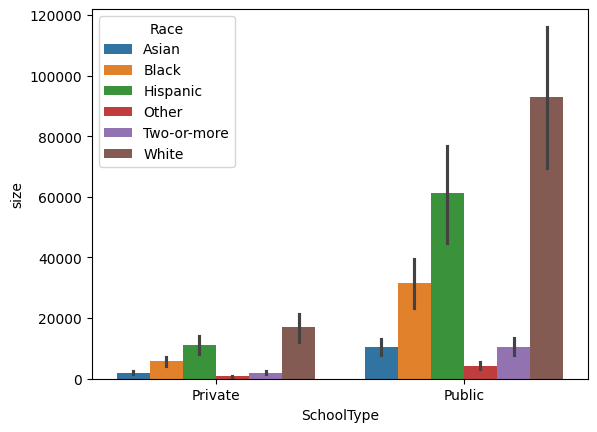

In [37]:
sns.barplot(data = q11,x = "SchoolType",y = "size",hue="Race")

* majority of the people who attend the scholl irrespectiv of their race choosse to study in public schools

<Axes: xlabel='Race', ylabel='size'>

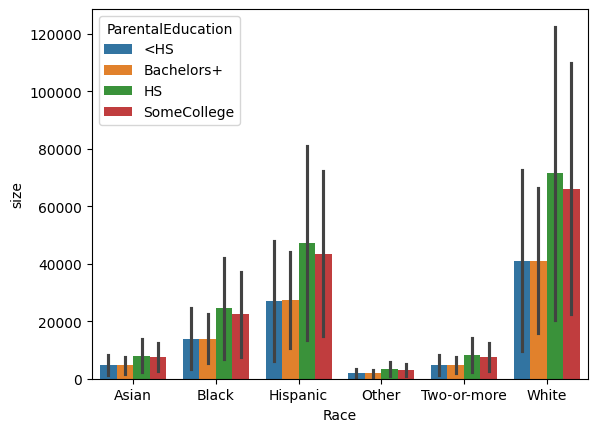

In [44]:
sns.barplot(data = q11,x = "Race",y = "size",hue="ParentalEducation")

* the other races have the lowest literacy rate
* The white race they have the higher Literacy rate among the rest of them
* by considering this graph we can say that the asians, other Two-or-More has lowest literacy rate among the rest of the races

#### What is the Average GPA of Asian , Other , and Two or more

In [66]:
q12 = df[["Race","GPA"]].groupby(["Race"],as_index = False)["GPA"].agg([mean,len])
q12.sort_values("mean",ascending = False)

C:\Users\USER\AppData\Local\Temp\ipykernel_16328\3485829808.py:1: FutureWarning: The provided callable <function mean at 0x000001763CFEAF80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  q12 = df[["Race","GPA"]].groupby(["Race"],as_index = False)["GPA"].agg([mean,len])


,Race,mean,len
3,Other,2.998109,20256
0,Asian,2.997407,49933
4,Two-or-more,2.997155,50079
1,Black,2.997058,149683
5,White,2.996864,439714
2,Hispanic,2.996177,290332


* even thought the three races have low literacy rate they have hte highest average GPA Scores

#### Students of which race has parttime job and less parentsupport 

In [76]:
q13 = df.loc[(df["ParentSupport"] == 0) & (df["PartTimeJob"] == 1),["Race","ParentalEducation","GPA"]]
q13 = q13.groupby(["ParentalEducation","Race"],as_index = True)["GPA"].agg([mean,len])
q13.sort_values("mean",ascending = False)

C:\Users\USER\AppData\Local\Temp\ipykernel_16328\244775003.py:2: FutureWarning: The provided callable <function mean at 0x000001763CFEAF80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  q13 = q13.groupby(["ParentalEducation","Race"],as_index = True)["GPA"].agg([mean,len])


mean    len
ParentalEducation Race                        
<HS               Asian        3.017104   1362
                  Two-or-more  3.010947   1344
Bachelors+        Black        3.008106   1733
HS                Black        3.004990   5791
Bachelors+        Hispanic     3.004132   3503
SomeCollege       White        3.003478  12013
HS                Two-or-more  3.001034   1914
                  Asian        3.000154   1863
Bachelors+        Two-or-more  2.998564    638
SomeCollege       Hispanic     2.998413   7865
HS                Hispanic     2.997212  11019
<HS               White        2.996480  11931
HS                White        2.995619  16685
Bachelors+        White        2.993656   5201
HS                Other        2.990836    778
<HS               Hispanic     2.990506   7824
                  Black        2.989550   4014
SomeCollege       Asian        2.989016   1386
                  Black        2.988214   4124
                  Two-or-more  2.986531   1362
                  Other        2.985410    520
Bachelors+        Asian        2.984050    537
<HS               Other        2.983999    545
Bachelors+        Other        2.941414    254

In [77]:
q14 = df.loc[~((df["ParentSupport"] == 0) & (df["PartTimeJob"] == 1)),["Race","ParentalEducation","GPA"]]
q14 = q14.groupby(["ParentalEducation","Race"],as_index = True)["GPA"].agg([mean,len])
q14.sort_values("mean",ascending = False)

C:\Users\USER\AppData\Local\Temp\ipykernel_16328\2669209565.py:2: FutureWarning: The provided callable <function mean at 0x000001763CFEAF80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  q14 = q14.groupby(["ParentalEducation","Race"],as_index = True)["GPA"].agg([mean,len])


mean     len
ParentalEducation Race                         
SomeCollege       Two-or-more  3.003645   13618
HS                Other        3.003151    5847
SomeCollege       Other        3.001483    5544
<HS               Asian        2.999455    8014
                  Other        2.999364    3245
Bachelors+        Asian        2.999355    8770
HS                Black        2.999009   43111
SomeCollege       White        2.997732  120259
<HS               Black        2.997493   23894
HS                White        2.997034  126189
<HS               Hispanic     2.996752   46412
HS                Hispanic     2.996546   83381
Bachelors+        Two-or-more  2.996208    8874
HS                Asian        2.996144   14256
<HS               Two-or-more  2.996046    7895
SomeCollege       Black        2.995972   40833
                  Hispanic     2.995935   79211
<HS               White        2.995924   70368
Bachelors+        White        2.995604   77068
SomeCollege       Asian        2.995324   13745
Bachelors+        Black        2.995198   26183
                  Hispanic     2.995183   51117
                  Other        2.993029    3523
HS                Two-or-more  2.991363   14434

mean     len
ParentalEducation Race                         
<HS               Asian        3.017104    1362
                  Black        2.989550    4014
                  Hispanic     2.990506    7824
                  Other        2.983999     545
                  Two-or-more  3.010947    1344
                  White        2.996480   11931
Bachelors+        Asian        2.984050     537
                  Black        3.008106    1733
                  Hispanic     3.004132    3503
                  Other        2.941414     254
                  Two-or-more  2.998564     638
                  White        2.993656    5201
HS                Asian        3.000154    1863
                  Black        3.004990    5791
                  Hispanic     2.997212   11019
                  Other        2.990836     778
                  Two-or-more  3.001034    1914
                  White        2.995619   16685
SomeCollege       Asian        2.989016    1386
                  Black        2.988214    4124
                  Hispanic     2.998413    7865
                  Other        2.985410     520
                  Two-or-more  2.986531    1362
                  White        3.003478   12013
<HS               Asian        2.999455    8014
                  Black        2.997493   23894
                  Hispanic     2.996752   46412
                  Other        2.999364    3245
                  Two-or-more  2.996046    7895
                  White        2.995924   70368
Bachelors+        Asian        2.999355    8770
                  Black        2.995198   26183
                  Hispanic     2.995183   51117
                  Other        2.993029    3523
                  Two-or-more  2.996208    8874
                  White        2.995604   77068
HS                Asian        2.996144   14256
                  Black        2.999009   43111
                  Hispanic     2.996546   83381
                  Other        3.003151    5847
                  Two-or-more  2.991363   14434
                  White        2.997034  126189
SomeCollege       Asian        2.995324   13745
                  Black        2.995972   40833
                  Hispanic     2.995935   79211
                  Other        3.001483    5544
                  Two-or-more  3.003645   13618
                  White        2.997732  120259

<Axes: xlabel='mean', ylabel='len'>

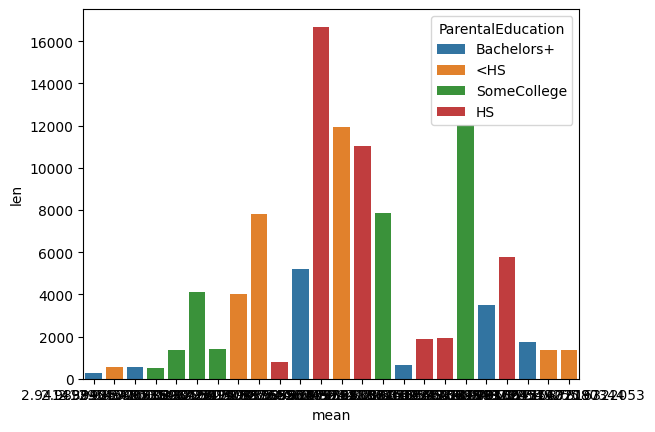

In [92]:
sns.barplot(data = q13,x = "mean", y = "len",hue="ParentalEducation") #student has no partime and spport from parent

* here we have the to scorers as <HS studying students
* the majority no of the students who are working in parttime and studying are HS while least beign Bachelor+

<Axes: xlabel='mean', ylabel='len'>

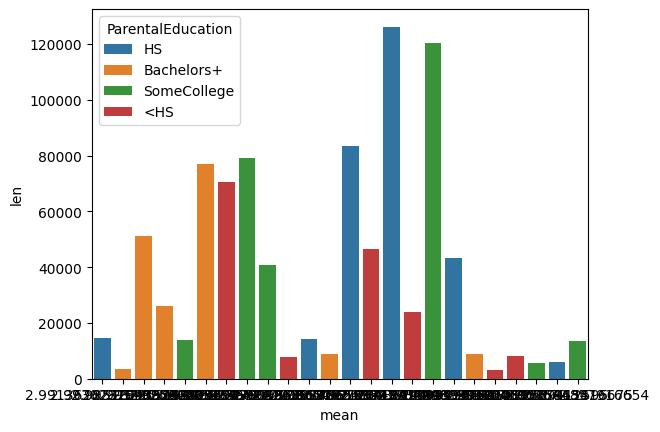

In [93]:
sns.barplot(data = q14,x = "mean", y = "len",hue="ParentalEducation")

* the students who scored highest in the previous group have got low average GPA
* and while the studnet  of some college collage who are no going to partime and getting suppor from the parents have had a greatr GPA

## conclusion

The majority of students in our dataset are pursuing their education while working part-time. Interestingly, this combination appears to have a positive effect on their academic performance — students with part-time jobs tend to achieve a higher GPA compared to those who do not work alongside their studies. However, as their level of education increases, a decline in GPA is observed among these part-time working students.

Additionally, we found that while students at higher education levels generally spend less time studying, their GPA still shows a slight improvement, indicating more efficient or focused learning strategies at advanced levels.

When examining educational preferences, most students expressed a preference for public schooling. In terms of race-based insights, students belonging to Asian backgrounds and those identifying with two or more races were fewer in number. However, despite their smaller population, these groups recorded the highest average GPA compared to other racial categories.